## **LiDAR Sensing: How Robots “See” the World**

In [13]:
!pip install shapely
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
import math
from shapely.geometry import Point, LineString, Polygon
import random

In [14]:
def generate_lidar_scan(sensor_position, obstacles, num_beams, max_range, scan_angle):
    """
    Generates an artificial 2D LiDAR scan.

    :param sensor_position: Tuple (x, y) representing the position of the LiDAR sensor.
    :param obstacles: List of tuples ((x1, y1), (x2, y2)) representing line segments as obstacles.
    :param num_beams: Number of LiDAR beams.
    :param max_range: Maximum range of the LiDAR.
    :param scan_angle: Angle range of the scan in degrees.
    :return: Numpy array of distances for each beam and angles.
    """
    angles = np.linspace(0, scan_angle * np.pi / 180, num_beams, endpoint=False)  # Angles for the scan.
    distances = np.full(num_beams, max_range)  # Initialize distances with the maximum range.

    for i, angle in enumerate(angles):
        direction = (math.cos(angle), math.sin(angle))
        beam_endpoint = (sensor_position[0] + direction[0] * max_range,
                         sensor_position[1] + direction[1] * max_range)

        for obstacle in obstacles:
            intersection_point = ray_segment_intersection(sensor_position, angle, obstacle[0], obstacle[1], max_range)
            if intersection_point is not None:
                distance = np.linalg.norm(np.array(sensor_position) - np.array(intersection_point))
                if distance < distances[i]:
                    distances[i] = distance

    return distances, angles

def ray_segment_intersection(p, theta, q, d, max_range):
    """
    Checks the intersection of a ray with a line segment.

    :param p: The origin point of the ray (x_p, y_p).
    :param theta: The angle of the ray in radians.
    :param q: Starting point of the line segment (x1, y1).
    :param d: Ending point of the line segment (x2, y2).
    :param max_range: Maximum range of the LiDAR.
    :return: Intersection point if within the segment and range, otherwise None.
    """
    # Define the endpoint of the ray
    ray_endpoint = (p[0] + max_range * np.cos(theta), p[1] + max_range * np.sin(theta))

    # Create LineString objects for the ray and the segment
    ray_line = LineString([p, ray_endpoint])
    segment_line = LineString([q, d])

    # Check for intersection
    intersection = ray_line.intersection(segment_line)

    # Validate the intersection point
    if intersection.is_empty or not intersection.is_simple or not intersection.geom_type == 'Point':
        return None

    intersection_point = (intersection.x, intersection.y)
    distance = np.linalg.norm(np.array(p) - np.array(intersection_point))

    return intersection_point if distance <= max_range else None

def generate_random_polygons(warehouse, num_obstacles, num_sides, radius, min_distance_from_origin):
    """
    Generates random polygons within the warehouse bounds.

    :param warehouse: List of tuples defining the warehouse boundary.
    :param num_obstacles: Number of random obstacles to generate.
    :param num_sides: Number of sides for each polygon.
    :param radius: Radius of each polygon.
    :param min_distance_from_origin: Minimum distance from the origin for obstacles.
    :return: List of line segments representing the obstacles.
    """
    warehouse_length = warehouse[0][0][1]
    warehouse_width = warehouse[0][1][0] - warehouse[1][0][0]
    x_min, x_max = warehouse[1][0][0], warehouse[0][1][0]
    y_min, y_max = -warehouse_length, warehouse_length

    def generate_polygon(center, radius, num_sides, rotation):
        angle = 2 * math.pi / num_sides
        return [(center[0] + radius * math.cos(i * angle + rotation),
                 center[1] + radius * math.sin(i * angle + rotation)) for i in range(num_sides)]

    polygons = []
    remaining_obstacles = num_obstacles

    while remaining_obstacles > 0:
        for i in range(num_obstacles):
            while True:
                # Generate a random center for the polygon
                center_x = random.uniform(x_min, x_max)
                center_y = random.uniform(y_min, y_max)

                # Ensure the polygon is at least `min_distance_from_origin` from the origin
                if math.dist((center_x, center_y), (0, 0)) < min_distance_from_origin:
                    continue

                rotation = random.uniform(0, 2 * math.pi)  # Random rotation angle

                # Determine the number of sides
                sides = num_sides if remaining_obstacles == num_obstacles else random.randint(2, max(2, num_sides))

                polygon = generate_polygon((center_x, center_y), radius, sides, rotation)

                # Check that the polygon is within the warehouse boundary and does not overlap others
                if all(x_min <= x <= x_max and y_min <= y <= y_max for x, y in polygon):
                    if all(not any(math.dist(p, q) < radius for p in poly for q in polygon) for poly in polygons):
                        polygons.append(polygon)
                        remaining_obstacles -= 1
                        break

    # Convert polygons to line segments
    segments = []
    for polygon in polygons:
        for i in range(len(polygon)):
            segments.append((polygon[i], polygon[(i + 1) % len(polygon)]))

    return segments

def calculate_valid_points(distances, angles, sensor_position, max_range):
    """
    Calculate the valid points from LiDAR distances and angles.

    :param distances: Numpy array of distances.
    :param angles: Numpy array of angles.
    :param sensor_position: Tuple (x, y) representing the LiDAR sensor position.
    :param max_range: Maximum range of the LiDAR.
    :return: Numpy array of valid (x, y) points.
    """
    valid_points = []
    for distance, angle in zip(distances, angles):
        if distance < max_range:
            x = sensor_position[0] + distance * np.cos(angle)
            y = sensor_position[1] + distance * np.sin(angle)
            valid_points.append((x, y))
    points = np.array(valid_points)
    return points

def plot_lidar_scan(obstacles, distances, angles, sensor_position, max_range, points, warehouse_length, warehouse_width):
    """
    Plots the LiDAR scan with obstacles and detected points.

    :param obstacles: List of line segments representing obstacles.
    :param distances: Numpy array of distances from the LiDAR scan.
    :param angles: Numpy array of angles from the LiDAR scan.
    :param sensor_position: Tuple (x, y) representing the LiDAR sensor position.
    :param max_range: Maximum range of the LiDAR.
    :param points: Numpy array of valid (x, y) points.
    :param warehouse_length: Length of the warehouse.
    :param warehouse_width: Width of the warehouse.
    """
    plt.figure(figsize=(12, 12))

    # Plot obstacles
    for obstacle in obstacles:
        plt.plot([obstacle[0][0], obstacle[1][0]], [obstacle[0][1], obstacle[1][1]], 'k-')

    # Plot LiDAR scan lines
    for distance, angle in zip(distances, angles):
        end_x = sensor_position[0] + distance * np.cos(angle)
        end_y = sensor_position[1] + distance * np.sin(angle)
        if distance < max_range:
            plt.plot([sensor_position[0], end_x], [sensor_position[1], end_y], 'r-', alpha=0.5)
        else:
            plt.plot([sensor_position[0], end_x], [sensor_position[1], end_y], 'r:', alpha=0.3)

    # Plot valid points if available
    if points is not None and len(points) > 0:
        plt.scatter(points[:, 0], points[:, 1], c='g', s=10)

    # Plot sensor position with an image centered at (0, 0)
    frame = mpimg.imread("assets/frame.png")
    height, width, _ = frame.shape
    scale_factor = 400 * 20 / max(warehouse_length, warehouse_width)
    extent = (-width / (2 * scale_factor), width / (2 * scale_factor), -height / (2 * scale_factor), height / (2 * scale_factor))
    plt.imshow(frame, extent=extent, aspect='auto', zorder=10)
    plt.text(sensor_position[0] + 0.15, sensor_position[1] - 0.3, "LIDAR", fontsize=8, color='black', fontweight='bold')

    # Set plot limits and aspect ratio
    plot_limit = max(warehouse_length / 2 + 1, warehouse_width / 2 + 1)
    plt.xlim(-plot_limit, plot_limit)
    plt.ylim(-plot_limit, plot_limit)
    plt.gca().set_aspect('equal', adjustable='box')

    # Set labels and title
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Synthetic 2D Lidar Simulated Scan')

    # Save the plot
    plt.savefig('assets/plot.png', dpi=300, bbox_inches='tight')

    # Display the plot
    plt.show()

In [ ]:
# Dimensions of the warehouse
warehouse_length = 18  # Length of the warehouse
warehouse_width = 18  # Width of the warehouse

# Define the warehouse boundaries as line segments
warehouse = [
    ((-warehouse_width / 2, warehouse_length / 2), (warehouse_width / 2, warehouse_length / 2)),  # Top boundary
    ((-warehouse_width / 2, warehouse_length / 2), (-warehouse_width / 2, -warehouse_length / 2)),  # Left boundary
    ((warehouse_width / 2, warehouse_length / 2), (warehouse_width / 2, -warehouse_length / 2)),  # Right boundary
    ((-warehouse_width / 2, -warehouse_length / 2), (warehouse_width / 2, -warehouse_length / 2))  # Bottom boundary
]

num_obstacles = 10  # Number of obstacles to generate
num_sides = 5  # Minimum number of sides for each obstacle polygon

obstacles_radius = 0.8  # Radius of obstacles
min_distance_from_origin = 2  # Minimum distance from origin for obstacle placement

# Generate random polygons as obstacles within the warehouse
random_polygons_segments = generate_random_polygons(warehouse, num_obstacles, num_sides, obstacles_radius, min_distance_from_origin)
# Combine warehouse boundaries and generated obstacle segments
obstacles = warehouse + random_polygons_segments

sensor_position = (0, 0)  # Position of the LiDAR sensor for simulation
num_beams = 360  # Determines how many beams (or rays) the LiDAR sensor will emit in a scan_angle.
max_range = 10.0  # Specifies the maximum distance up to which the LiDAR sensor can detect obstacles or objects.
scan_angle = 360  # Defines the total angular range covered by the LiDAR sensor for scanning.

distances, angles = generate_lidar_scan(sensor_position, obstacles, num_beams, max_range, scan_angle)
# Filter out points that do not encounter obstacles
points = calculate_valid_points(distances, angles, sensor_position, max_range)
plot_lidar_scan(obstacles, distances, angles, sensor_position, max_range, points, warehouse_length, warehouse_width)

## **Turning LiDAR Data into Perception & Planning**

In [ ]:
# 
!pip install PyYAML shapely numpy matplotlib

import sys
import os
import numpy as np
import matplotlib.pylab as pl
import yaml

%matplotlib inline

In [ ]:
class Obstacle():
    """
    Dynamic or static rectangular obstacle.
    """
    def __init__(self, centroid, dx, dy, angle=0, vel=[0, 0], acc=[0, 0]):
        self.centroid = centroid
        self.dx = dx
        self.dy = dy
        self.angle = angle
        self.vel = vel 
        self.acc = acc
        self.time = 0 

    def update(self, pos=None):
        """
        Update the position of the obstacle based on its velocity and acceleration.
        """
        if pos is None:
            # s = ut + 0.5at^2
            self.centroid[0] += self.vel[0] + 0.5 * self.acc[0]
            self.centroid[1] += self.vel[1] + 0.5 * self.acc[1]
            self.time += 1
        else:
            self.centroid = pos
            
        # Generate the four line segments of the rectangle
        # Using a simplified version for common 2D lidar simulation
        c, s = np.cos(self.angle), np.sin(self.angle)
        R = np.array(((c, -s), (s, c)))
        
        # Corners relative to centroid
        p1 = np.array([-self.dx/2, -self.dy/2])
        p2 = np.array([self.dx/2, -self.dy/2])
        p3 = np.array([self.dx/2, self.dy/2])
        p4 = np.array([-self.dx/2, self.dy/2])
        
        # Rotate and translate corners
        points = [self.centroid + R @ p for p in [p1, p2, p3, p4]]
        
        # Return segments as (x1, y1, x2, y2)
        return [(points[0][0], points[0][1], points[1][0], points[1][1]),
                (points[1][0], points[1][1], points[2][0], points[2][1]),
                (points[2][0], points[2][1], points[3][0], points[3][1]),
                (points[3][0], points[3][1], points[0][0], points[0][1])]
def get_intersection(a1, a2, b1, b2):
    def perp(a):
        return np.array([-a[1], a[0]])

    da, db, dp = a2-a1, b2-b1, a1-b1
    dap = perp(da)
    denom = np.dot(dap, db)
    if denom == 0: return None
    
    num = np.dot(dap, dp)
    intersct = np.array((num/denom.astype(float))*db + b1)

    delta = 1e-3
    if (min(a1[0], a2[0])-delta <= intersct[0] <= max(a1[0], a2[0])+delta and
        min(a1[1], a2[1])-delta <= intersct[1] <= max(a1[1], a2[1])+delta and
        min(b1[0], b2[0])-delta <= intersct[0] <= max(b1[0], b2[0])+delta and
        min(b1[1], b2[1])-delta <= intersct[1] <= max(b1[1], b2[1])+delta):
        return intersct
    return None

def get_laser_ref(segments, fov, n_reflections, max_dist, xytheta_robot):
    xy_robot, theta_robot = xytheta_robot[:2], xytheta_robot[2]
    # Center the FOV on the robot's heading
    angles = np.linspace(theta_robot - fov/2, theta_robot + fov/2, n_reflections)
    dist_theta = max_dist * np.ones(n_reflections)

    for seg_i in segments:
        p_start, p_end = np.array(seg_i[:2]), np.array(seg_i[2:])
        for j, theta in enumerate(angles):
            xy_max = xy_robot + np.array([max_dist*np.cos(theta), max_dist*np.sin(theta)])
            intersection = get_intersection(p_start, p_end, xy_robot, xy_max)
            if intersection is not None:
                r = np.linalg.norm(intersection - xy_robot)
                if r < dist_theta[j]: dist_theta[j] = r
    return dist_theta

def connect_segments(segments, resolution=0.1):
    points = []
    for s in segments:
        length = np.sqrt((s[2]-s[0])**2 + (s[3]-s[1])**2)
        if length == 0: continue
        num_pts = max(int(length / resolution), 2)
        x = np.linspace(s[0], s[2], num_pts)
        y = np.linspace(s[1], s[3], num_pts)
        points.append(np.vstack((x, y)).T)
    return np.vstack(points) if points else np.array([]).reshape(0,2)

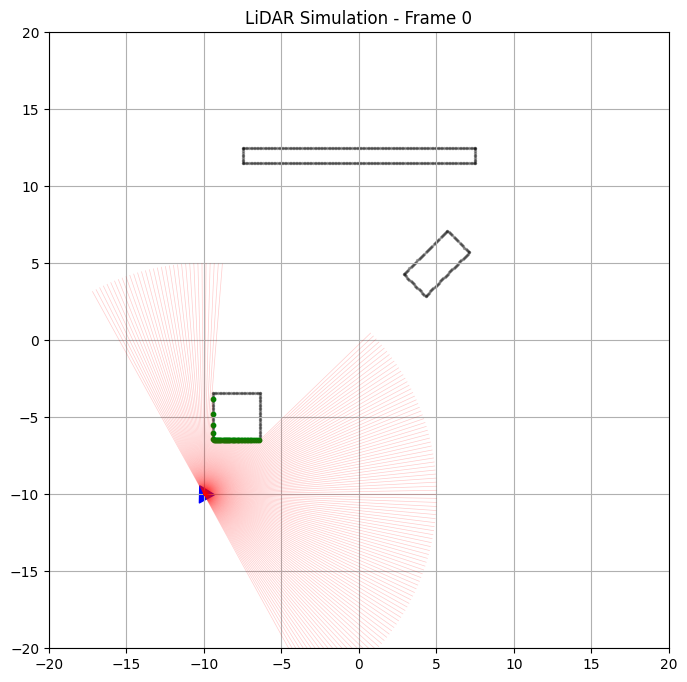

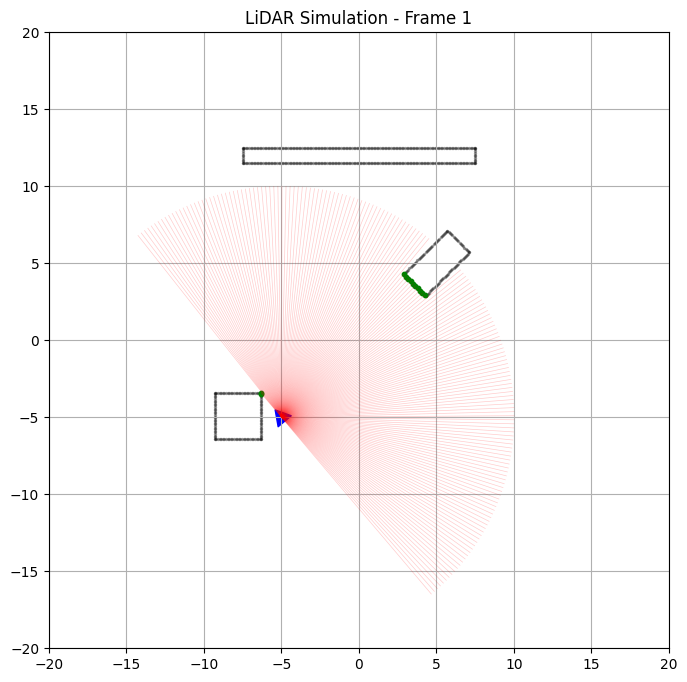

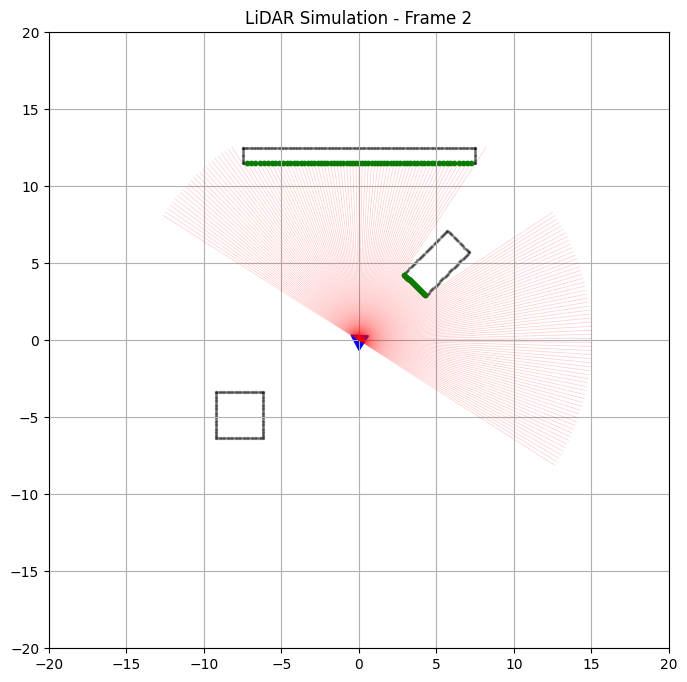

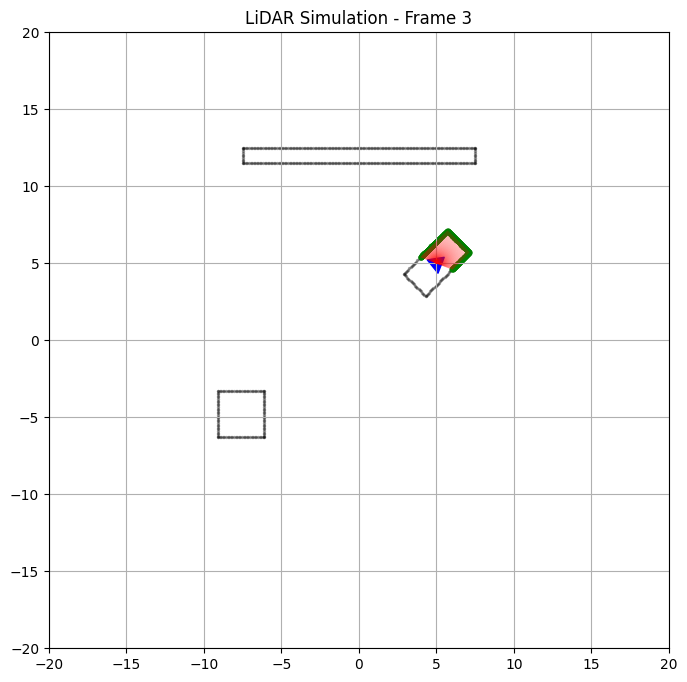

Simulation complete. Images saved in outputs/toy1_sim/


In [ ]:
# 1. YAML 
environment_config = {
    'area': {'x_min': -20, 'x_max': 20, 'y_min': -20, 'y_max': 20},
    'obstacles': [
        {'centroid_x': 5, 'centroid_y': 5, 'dx': 4, 'dy': 2, 'orientation': 45, 'velocity_x': 0, 'velocity_y': 0},
        {'centroid_x': -8, 'centroid_y': -5, 'dx': 3, 'dy': 3, 'orientation': 0, 'velocity_x': 0.1, 'velocity_y': 0.05},
        {'centroid_x': 0, 'centroid_y': 12, 'dx': 15, 'dy': 1, 'orientation': 0, 'velocity_x': 0, 'velocity_y': 0}
    ]
}

# 2. 
obs_objs = []
for o in environment_config['obstacles']:
    obs_objs.append(Obstacle([o['centroid_x'], o['centroid_y']], o['dx'], o['dy'], 
                             o['orientation']*np.pi/180, [o.get('velocity_x', 0), o.get('velocity_y', 0)]))

area = environment_config['area']
limits = (area['x_min'], area['x_max'], area['y_min'], area['y_max'])

# 3. 
n_reflections = 180
fov = np.deg2rad(180)
max_dist = 15
#  (x, y, heading_rad)
robot_path = [[-10, -10, 0.5], [-5, -5, 0.7], [0, 0, 1.0], [5, 5, 1.2]]

# 4. 
os.makedirs('outputs/toy1_sim', exist_ok=True)

for t, pose in enumerate(robot_path):
    pose = np.array(pose)
    all_segments = []
    for ob in obs_objs:
        all_segments += ob.update()
    
    #  LiDAR data
    distances = get_laser_ref(all_segments, fov, n_reflections, max_dist, pose)
    
    # 
    pl.figure(figsize=(8, 8))
    # 
    if all_segments:
        contour = connect_segments(all_segments)
        pl.scatter(contour[:,0], contour[:,1], s=2, c='black', alpha=0.3)
    
    # 
    angles = np.linspace(pose[2] - fov/2, pose[2] + fov/2, n_reflections)
    for i, ang in enumerate(angles):
        end_x = pose[0] + distances[i] * np.cos(ang)
        end_y = pose[1] + distances[i] * np.sin(ang)
        pl.plot([pose[0], end_x], [pose[1], end_y], 'r-', lw=0.5, alpha=0.2)
        if distances[i] < max_dist:
            pl.scatter(end_x, end_y, c='green', s=10)
            
    # 
    pl.scatter(pose[0], pose[1], marker=(3, 0, np.rad2deg(pose[2])), s=200, c='blue', label='Robot')
    
    pl.xlim(limits[0], limits[1]); pl.ylim(limits[2], limits[3])
    pl.title(f"LiDAR Simulation - Frame {t}")
    pl.grid(True)
    pl.savefig(f'outputs/toy1_sim/frame_{t}.png')
    pl.show()

print("Simulation complete. Images saved in outputs/toy1_sim/")

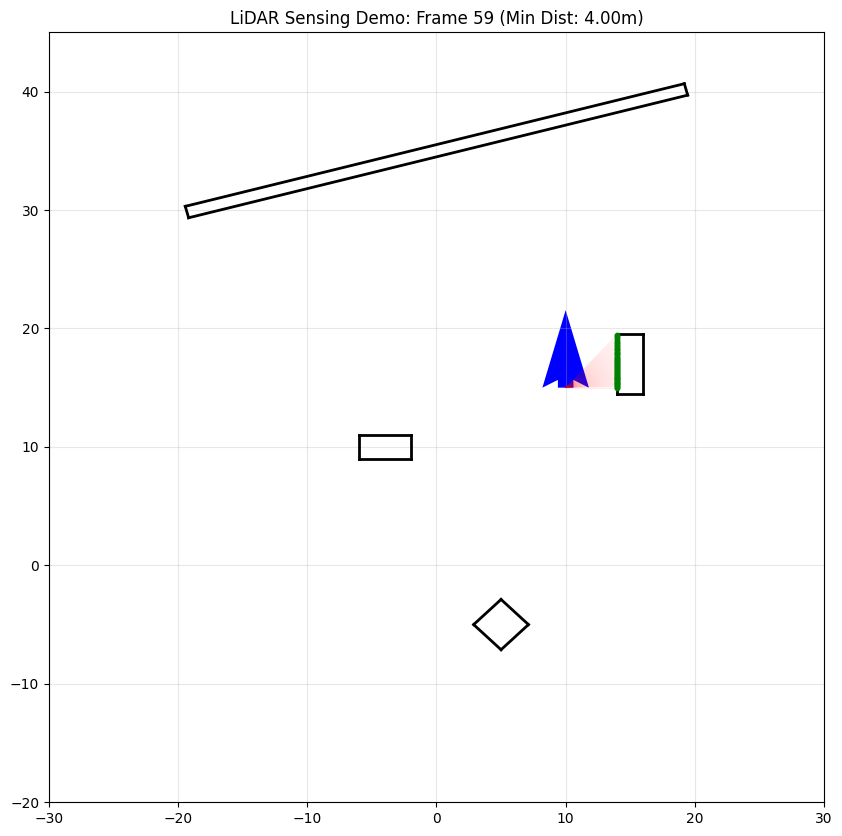

In [26]:

def run_lidar_scan(segments, robot_pose, fov_deg=180, n_beams=180, max_range=15):
    """ 模拟 LiDAR 射线投射 """
    x_r, y_r, theta_r = robot_pose
    angles = np.linspace(theta_r - np.radians(fov_deg)/2, 
                         theta_r + np.radians(fov_deg)/2, n_beams)
    
    ranges = np.ones(n_beams) * max_range
    points = [None] * n_beams

    for i, angle in enumerate(angles):
        beam_end = np.array([x_r + max_range * np.cos(angle), 
                             y_r + max_range * np.sin(angle)])
        start_pt = np.array([x_r, y_r])
        
        for seg in segments:
            p1, p2 = np.array(seg[:2]), np.array(seg[2:])
            inter = get_intersection(p1, p2, start_pt, beam_end)
            if inter is not None:
                d = np.linalg.norm(inter - start_pt)
                if d < ranges[i]:
                    ranges[i] = d
                    points[i] = inter
    return points, ranges


obs_list = [
    Obstacle(centroid=[0, 35], dx=40, dy=1, angle=15),      # 
    Obstacle(centroid=[-10, 10], dx=4, dy=2, vel=[0.1, 0]),  #  
    Obstacle(centroid=[15, 20], dx=2, dy=5, vel=[0, -0.05]), #  
    Obstacle(centroid=[5, -5], dx=3, dy=3, angle=45)         # 
]

#  (x, y, theta)
steps = 60
path_x = np.linspace(-15, 10, steps)
path_y = np.linspace(-10, 15, steps)
path_theta = np.linspace(0, np.pi/2, steps)

plt.figure(figsize=(10, 10))

for i in range(steps):
    pose = [path_x[i], path_y[i], path_theta[i]]
    
    current_segments = []
    for ob in obs_list:
        current_segments += ob.update()
         
    points, ranges = run_lidar_scan(current_segments, pose)
    

    min_dist = np.min(ranges)
    is_collision = min_dist < 0.8   
    

    plt.clf()

    for seg in current_segments:
        plt.plot([seg[0], seg[2]], [seg[1], seg[3]], 'k-', lw=2)
    

    for pt in points:
        if pt is not None:
            plt.plot([pose[0], pt[0]], [pose[1], pt[1]], 'r-', alpha=0.1, lw=0.5)
            plt.scatter(pt[0], pt[1], c='g', s=10, zorder=3) # 绿色点云
            

    robot_color = 'red' if is_collision else 'blue'
    plt.quiver(pose[0], pose[1], np.cos(pose[2]), np.sin(pose[2]), 
               color=robot_color, scale=10, width=0.02, label='Robot')

    if is_collision:
        plt.text(pose[0], pose[1]+2, "COLLISION!", color='red', 
                 fontsize=15, fontweight='bold', ha='center')
    
    plt.xlim(-30, 30); plt.ylim(-20, 45)
    plt.title(f"LiDAR Sensing Demo: Frame {i} (Min Dist: {min_dist:.2f}m)")
    plt.grid(True, alpha=0.3)
    
    display.clear_output(wait=True)
    display.display(plt.gcf())
    time.sleep(0.05)

plt.close()

## **Learning to Drive: RL-Based Control in Action**

In [1]:

!pip install highway-env
!pip install git+https://github.com/DLR-RM/stable-baselines3
!pip install tensorboardx gym pyvirtualdisplay
!apt-get install -y xvfb ffmpeg
!git clone https://github.com/Farama-Foundation/HighwayEnv.git 2> /dev/null

  Using cached highway_env-1.10.2-py3-none-any.whl.metadata (16 kB)
  Using cached pygame-2.6.1.tar.gz (14.8 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached scipy-1.16.3-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
Using cached highway_env-1.10.2-py3-none-any.whl (107 kB)
Using cached scipy-1.16.3-cp314-cp314-macosx_14_0_arm64.whl (20.9 MB)
  error: subprocess-exited-with-error
  
  × Building wheel for pygame (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [14 lines of output]
      Skipping Cython compilation
      src_c/_sdl2/sdl2.c:1237:10: fatal error: 'SDL.h' file not found
       1237 | #include "SDL.h"
            |          ^~~~~~~
      1 error generated.
      
      ---
      For help with compilation see:
          https://www.pygame.org/wiki/MacCompile
      To contribute to pygame development see:
          https://www.pygame.org/contribute.ht

In [1]:
import gymnasium as gym
import highway_env
import sys

gym.register_envs(highway_env)

from stable_baselines3 import DQN

%load_ext tensorboard
from tqdm.notebook import trange

sys.path.insert(0, '/content/HighwayEnv/scripts/')
from utils import record_videos, show_videos

ModuleNotFoundError: No module named 'highway_env'

In [ ]:
%tensorboard --logdir "highway_dqn"
model = DQN('MlpPolicy', 'highway-fast-v0',
                policy_kwargs=dict(net_arch=[256, 256]),
                learning_rate=5e-4,
                buffer_size=15000,
                learning_starts=200,
                batch_size=32,
                gamma=0.8,
                train_freq=1,
                gradient_steps=1,
                target_update_interval=50,
                exploration_fraction=0.7,
                verbose=1,
                tensorboard_log='highway_dqn/')
model.learn(int(2e4))

In [ ]:
env = gym.make('highway-fast-v0', render_mode='rgb_array')
env = record_videos(env)
for episode in trange(3, desc='Test episodes'):
    (obs, info), done = env.reset(), False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(int(action))
env.close()
show_videos()